# Underfitting Model

by Niklas Vogel and Kevin Stupar

This notebook creates an optimized model and evaluates it using cross validation.
We used the `intel image classfification` data for thrainging out model.

## Steps
- Loading, splitting and inspection fo the data
- Preparing the model and fitting it and evaluate it
- Train multiple models using cross validation and evaluate the results
- Run on Test data adn Evaluate

## Setup
Before executing this please make sure you did download and extract the [data](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc).
The Data must look like this: \<proj_name\>/.cache/extracted/seg_train/

Alternatively you can run setup.py

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Loading and splitting the data

The dataset contains six categories: buildings, forest, glacier, mountain, sea and street.
All classes have 2000 samples except street which has only 150.
This is guaranteed by our setup, which deletes excess images.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to 64*64 pixels.
Next we shuffle the data using a seed so there is randomness in which go into training, validation and test split.
Using the seed we ensure the splits look the same for all models, but can be changed.

After shuffling we split the data into training, validation and test data.
- training: 56% (80% of non-test)
- validation: 14% (20% of non-test)
- test: 30%

After shuffling we split the data into 3 sections, where the first one is the training and the last one the test data.

In [11]:
from helper import *
from tensorflow.keras import layers, models, regularizers

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.
Since we only have 150 streets, we will probably not see them here, but note that the images of streets often include buildings on the side.
This will be important later on.

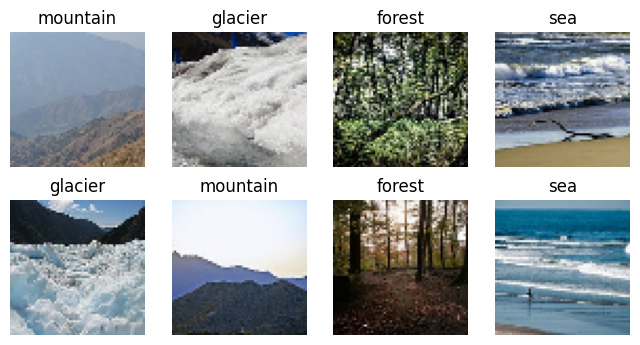

In [12]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.

Also we can see that the data is split quite equally over all 3 splits.

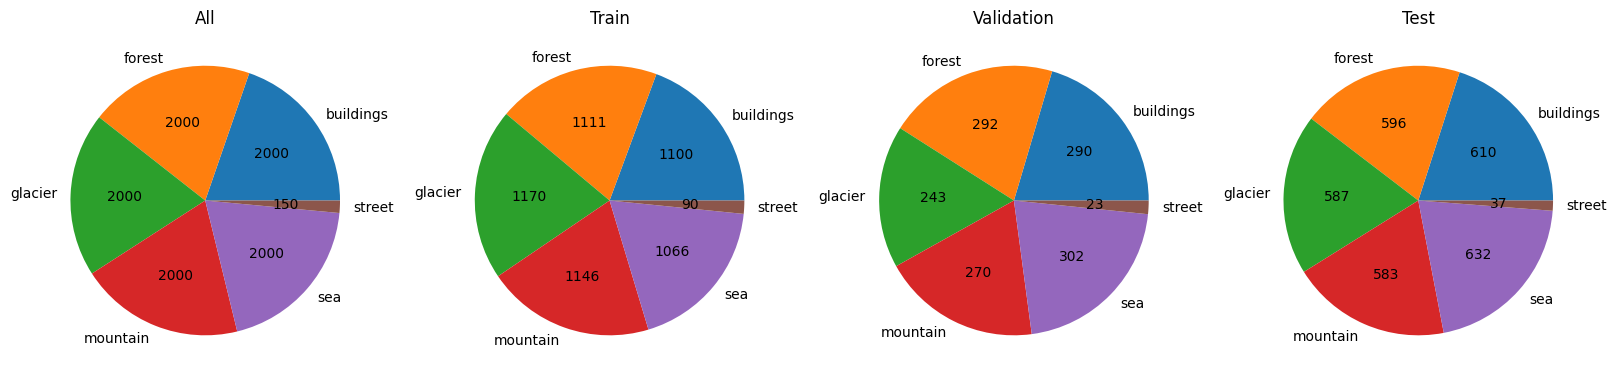

In [13]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

To improve the overfitting model we chose to add a dropout layer before the dense layer and add regularization for the last 2 convolutional as well as the dense layer. After some testing we found that not using regularization on the first two convolutional layers improves how easy it is to fine tune the model and therefore the performance.

The dropout layer before the dense layer is optimal vor reducing noise going into the final layer.

The hyperparameters were chosen by the KerasTuner, which checked nearly 200 different combinations of the hyperparameter, which eventually lead to a dropout of `0.4` and a lamda of `0.0015`.

Both these hyperparameters should help to get rid of the overfitting and achieve a better accuracy and loss on unseen data, than the overfitting model.

In [14]:
def create_model():
    dropout = 0.4
    regularizer = regularizers.l2(0.002)

    new_model = models.Sequential([
        layers.Input(shape=image_size + (3,)),
        layers.Rescaling(1./255),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", kernel_regularizer=regularizer),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation="relu", kernel_regularizer=regularizer),

        layers.Flatten(),
        layers.Dropout(dropout),
        layers.Dense(len(label_names), activation="softmax", kernel_regularizer=regularizer)
    ])
    new_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return new_model

model = create_model()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 29, 29, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,846 (530.65 KB)

 Trainable params: 135,846 (530.65 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we train the model for 30 epochs, as we did for the other two.

In [ ]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.4438 - loss: 1.4151 - val_accuracy: 0.5113 - val_loss: 1.2148
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5807 - loss: 1.0968 - val_accuracy: 0.6183 - val_loss: 1.0274
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6210 - loss: 1.0076 - val_accuracy: 0.6486 - val_loss: 0.9650
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6820 - loss: 0.9019 - val_accuracy: 0.7345 - val_loss: 0.8161
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7111 - loss: 0.8405 - val_accuracy: 0.7535 - val_loss: 0.7416
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7456 - loss: 0.7720 - val_accuracy: 0.7965 - val_loss: 0.6462
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7658 - loss: 0.7298 - val_accuracy: 0.7789 - val_loss: 0.6807
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7800 - loss: 0.6880 - 

# Evaluating the model

## Preparing
To evaluate the model we first run some images through the model and look at the predictions the model has made.

After that we use those prediction together with the true values to plot some graphs and evaluate how good the models behaves and if its more optimal then the previous models.

## Plots
### Accuracy/Loss
The first two plots show us the accuracy and the loss, where the loss is in a log y-scale, to better see the difference between the Epochs.

### Confusion Matrix
We have 4 different confusion matrices plotted, On the y-scale we have th actual labes and on the x-scale is what the model predicted.

### Scores
The last three plots show us some important training metrics such as f1-score, precision and recall.

Validation accuracy: 0.8697183132171631
Validation Loss: 0.5161101222038269


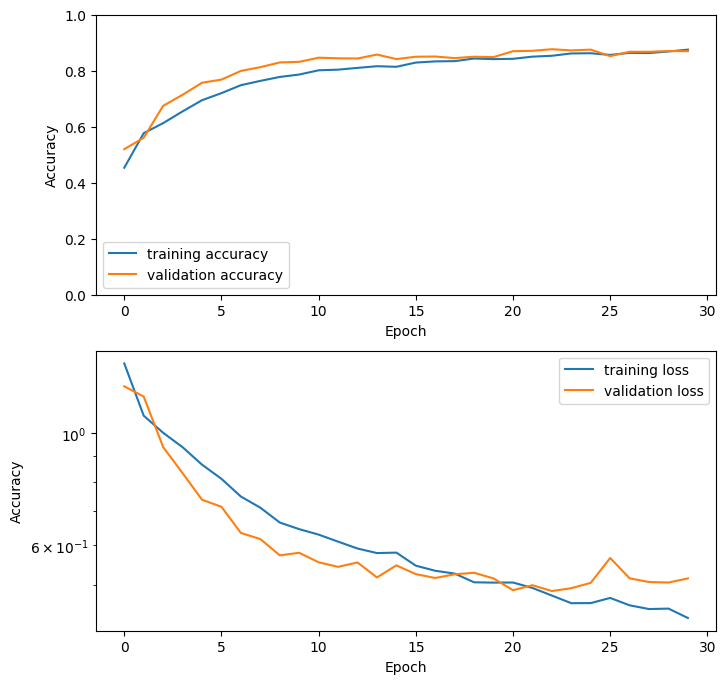

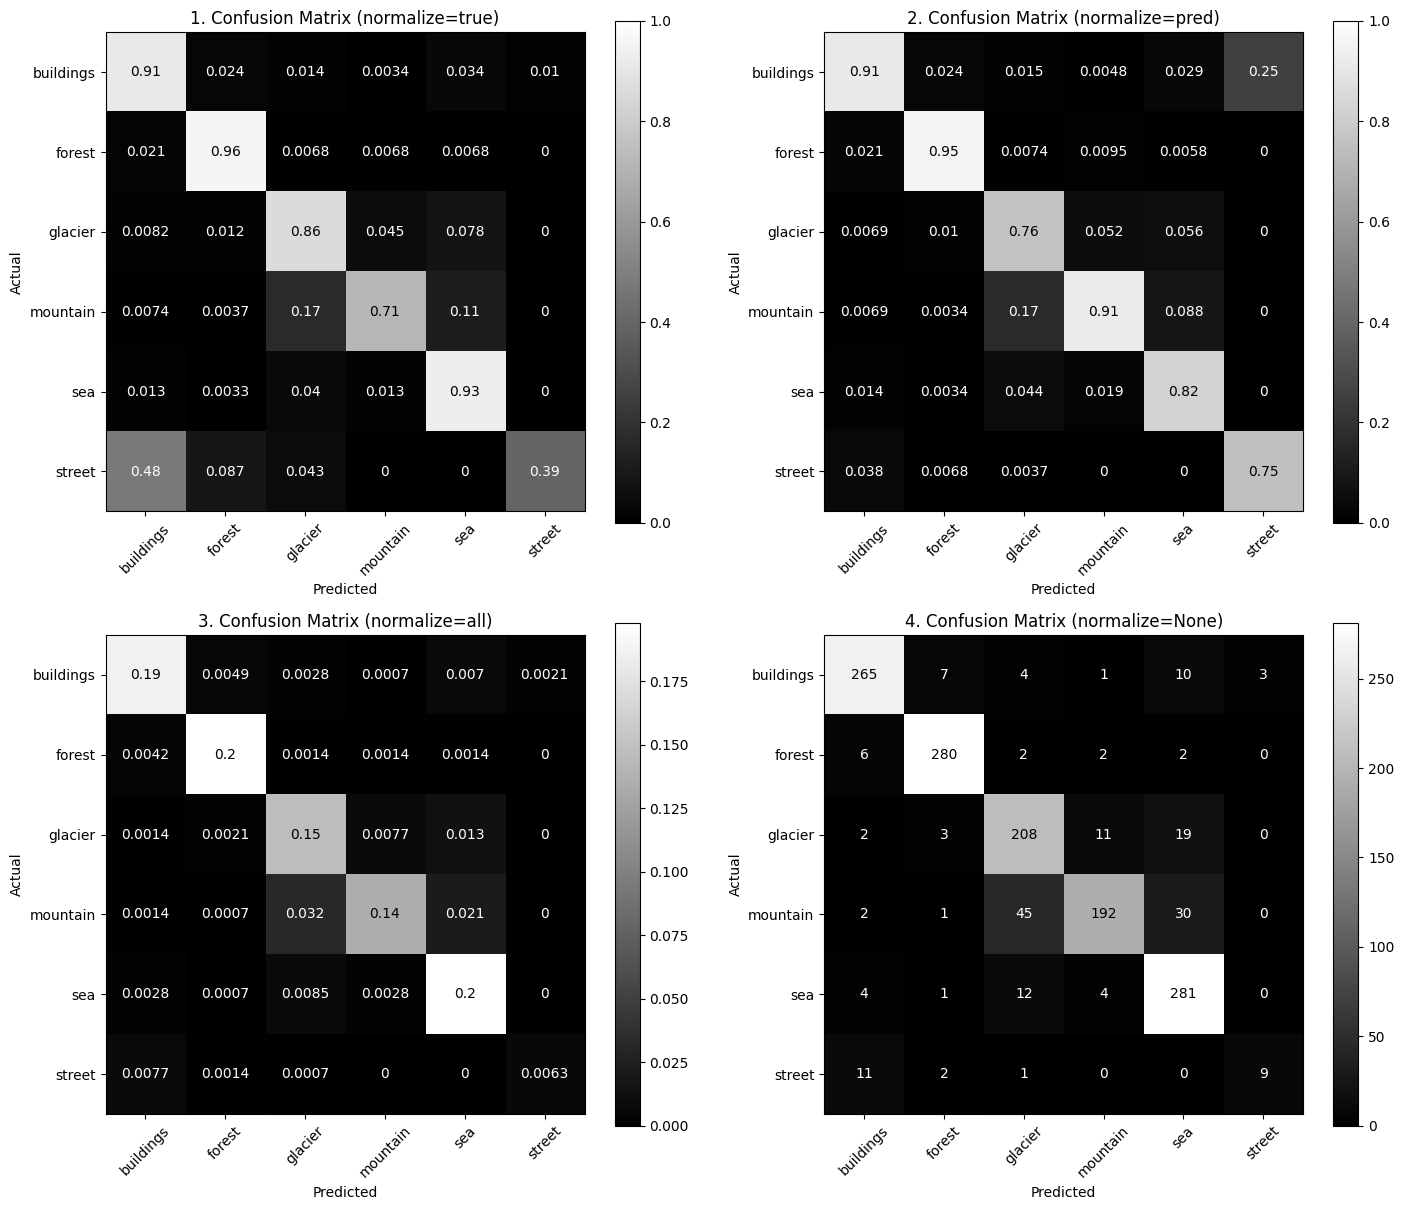

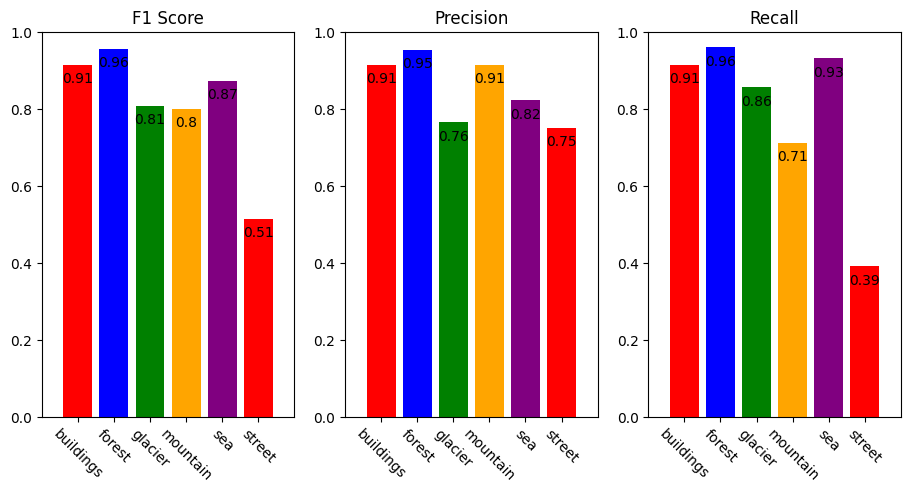

In [6]:
true, pred, pred_raw = calculate_predictions(model, validation_images.batch(batch_size))

print_accuracy_and_loss(model, validation_images.batch(batch_size))
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion
- Overall performance: The model has a training accuracy of about 0.875 and a validation accuracy of about 0.87. Our model performes similar on training und unsee data which is great.
- Accuracy: Training accuracy and validation being close and high is what w want to see. This means our model stopped learning random noise from the images. The model is not overfitting anymore.
- Loss: Validation loss is also quite close to training loss, which is good. Our model has similar confidence when predicting unseen data.
- Confusion Metrix:
  1. Streets samples still often gets predicted as building but now its a lot better. The model learned some key street features.
  2. Looking at street we see that most street predictions now actually also are streets, somthing that we didn't have in the models before. The model also struggles less with glacier and mountain (also seen in 1.).
  3. Comparing it to the overfitting model we see general approvement across the board.
  4. We notice that matrix 3. is a bit misleading. Matrix 3 has 2 classes which look very good. But here we see that those 2 classes have more data than the rest. Each those classes has around 21.5% of validation samples. Other classes have around 17%-19%.
- Training metrics
    - F1 score: Here we can again see that the model handels the unbalance of street in our dataset way better the before.
    - Precision: The model now predicts street quit good, nearly as good as glacier.
    - Recall: Street still gets predicted less but in comparison to overfitting it is a huge improvement.

# Cross Validation

To make sure we did not only get lucky with our hyperparameters on the previous model we use cross validation with 5 folds. This will give us an average accuracy and loss for 5 different training splits.

In [7]:
cv_results = execute_cv(create_model, dataset=train_images.concatenate(validation_images), folds=5, epochs=30)

Fold 1 / 5
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4595 - loss: 1.3607 - val_accuracy: 0.5574 - val_loss: 1.1758
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5625 - loss: 1.0896 - val_accuracy: 0.6348 - val_loss: 0.9533
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6234 - loss: 0.9844 - val_accuracy: 0.6770 - val_loss: 0.9540
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6763 - loss: 0.8960 - val_accuracy: 0.6981 - val_loss: 0.8584
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7049 - loss: 0.8337 - val_accuracy: 0.7467 - val_loss: 0.7655
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7335 - loss: 0.7699 - val_accuracy: 0.7157 - val_loss: 0.8012
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7453 - loss: 0.7550 - val_accuracy: 0.7445 - val_loss: 0.7355
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7621 - loss: 0.7065

Now we want to see how they performed compared to each other. Therefore, we look at the mean and standard deviation of the 5 scores `accuracy` and `loss` per train/validation and the `F1` score only for the validation.

We see that all folds performed similar. We can safely say that the model and our chosen hyperparameters are generally good.

Mean	Std. dev.	Name
0.8356	0.0165		Accuracy
0.5863	0.0431		Loss


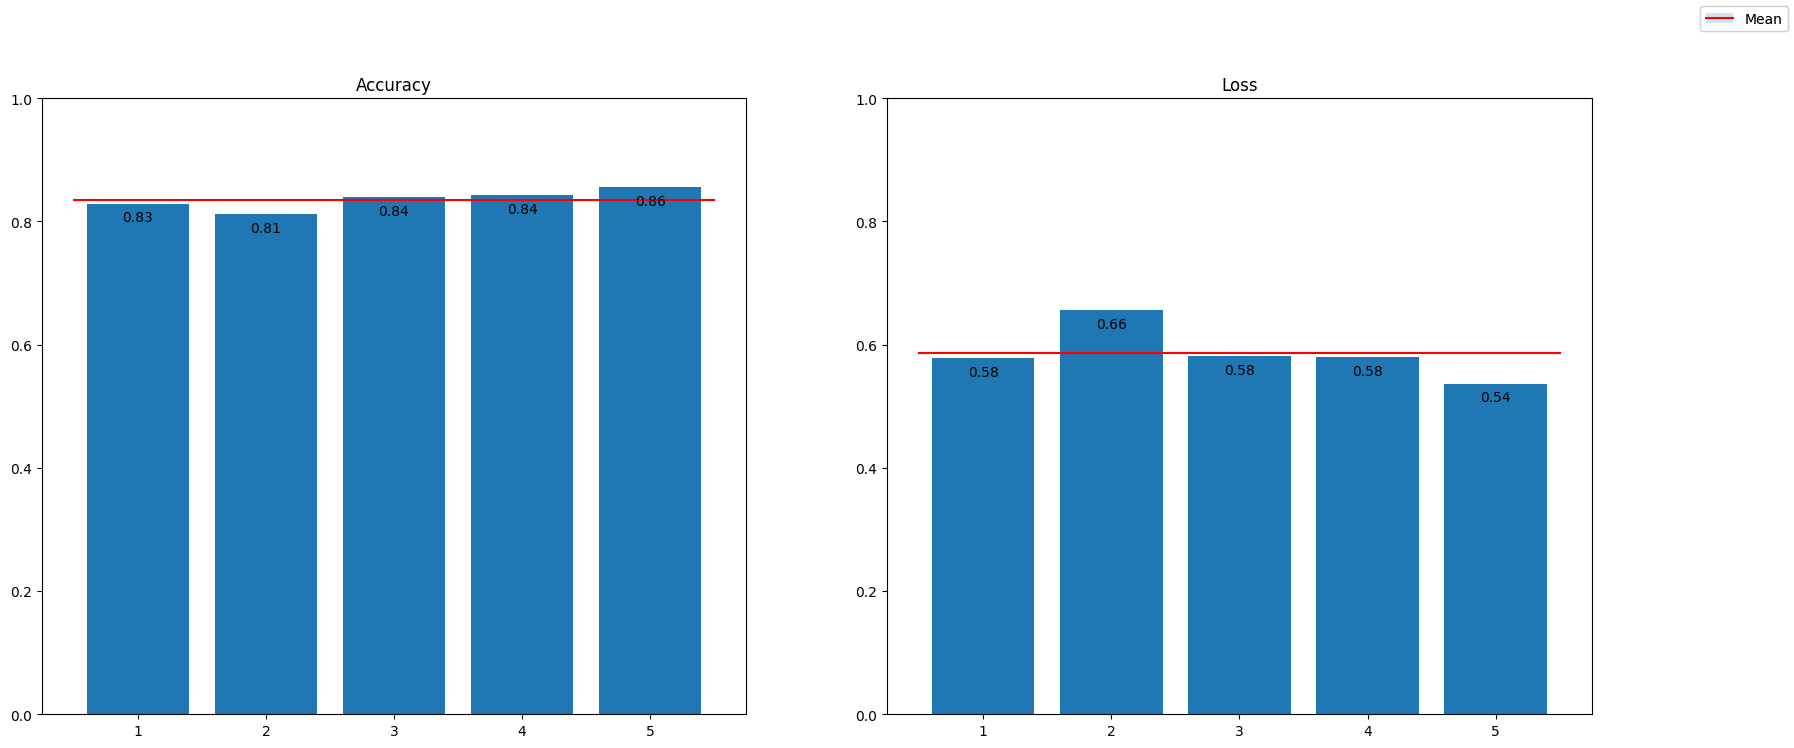

In [8]:
print("Mean\tStd. dev.\tName")
for name, values in cv_results.items():
    print(f"{mean(values):.4f}\t{stdev(values):.4f}\t\t{name}")

plot_cv_results(cv_results)

# Evaluating with the Test data

Since we only used the train and validation data until now, it is time to see, how good the model is on our unused test data.

To do this we use the trained model and predict the labels with the test data. This will tell us if our model is favoring the validation data or if the model can be applied for classifying any imager (of those classes).

And as we can see the mean accuracy (0.835) and loss (0.585) of k-folds are similar to the accuracy (0.84) and loss (0.59) of the predictions on the test data.


In [10]:
print_accuracy_and_loss(model, test_images.batch(batch_size))

Validation accuracy: 0.841050922870636
Validation Loss: 0.5882076621055603
